In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from utils import utils_ml 

from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.feature_selection import VarianceThreshold

In [34]:
# import pickle
# with open('fold_accuracies_r3.pkl', 'rb') as f:
#     feature_importances = pickle.load(f)
# feature_importances

In [11]:
import numpy as np
import gc
import pickle
import glob
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
from catboost import CatBoostRegressor, Pool
import sys


# Automatically find the matching file
input_files = glob.glob('features_selected*.npy')
if not input_files:
    raise FileNotFoundError("No features_filtered*.npy file found in current directory")
input_path = input_files[0]

# Load memory-mapped array
print(f"Loading features from {input_path}")
X_arr = np.load(input_path, mmap_mode='r').astype(np.float32)

# Class mapping dictionary
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],  # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}



# File paths
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

# Load labels
print("Loading labels...")
y_arr_classification = np.array([
    np.tile(i, np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) 
    for i in np.arange(num_files)
]).flatten()


fold_accuracies = []

# Use k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_index, val_index) in enumerate(kf.split(X_arr)):
    print(f"  Fold {fold+1}/5")
    # Extract current fold data with selected feature count
    X_train, X_val = X_arr[train_index].astype(np.float32), X_arr[val_index].astype(np.float32)
    y_train, y_val = y_arr_classification[train_index], y_arr_classification[val_index]

    # Train model
    model = CatBoostRegressor(
        loss_function="RMSE",
        iterations=10000,
        verbose=100,
        early_stopping_rounds=10
    )

    model.fit(
        X_train, y_train, 
        eval_set=(X_val, y_val), 
        use_best_model=True,
        plot=False
    )

    # Save model
    model_path = f"models/catboost_model_r1_fold{fold}.cbm"
    # model.save_model(model_path)
    
    # Predict and evaluate

    y_pred = np.abs(np.round(model.predict(X_val)))
    acc = np.sum(y_pred.flatten()==y_val)/np.sum(np.ones_like(y_val))
    fold_accuracies.append(acc)
    print(f"  Fold accuracy: {acc:.4f}")

    # Clean up
    # del model, X_train, X_val, y_train, y_val
    gc.collect()

    break

# Save fold accuracies
acc_file = f"fold_accuracies_r1.pkl" 
# with open(acc_file, "wb") as f:
#     pickle.dump(fold_accuracies, f)
    

print("Pipeline execution complete!")

Loading features from features_selected_T11Bg.npy
Loading labels...
  Fold 1/5
Learning rate set to 0.030276
0:	learn: 10.0510321	test: 10.0487640	best: 10.0487640 (0)	total: 32.2ms	remaining: 5m 22s
100:	learn: 8.7773856	test: 8.7712390	best: 8.7712390 (100)	total: 3.48s	remaining: 5m 41s
200:	learn: 8.6013648	test: 8.6006295	best: 8.6006295 (200)	total: 6.66s	remaining: 5m 24s
300:	learn: 8.5024013	test: 8.5092211	best: 8.5092211 (300)	total: 9.83s	remaining: 5m 16s
400:	learn: 8.4337472	test: 8.4472790	best: 8.4472790 (400)	total: 13s	remaining: 5m 12s
500:	learn: 8.3725589	test: 8.3941131	best: 8.3941131 (500)	total: 16.2s	remaining: 5m 7s
600:	learn: 8.3225207	test: 8.3535452	best: 8.3535452 (600)	total: 19.5s	remaining: 5m 4s
700:	learn: 8.2788326	test: 8.3191602	best: 8.3191602 (700)	total: 22.6s	remaining: 5m
800:	learn: 8.2410793	test: 8.2900930	best: 8.2900930 (800)	total: 25.8s	remaining: 4m 56s
900:	learn: 8.2067144	test: 8.2643353	best: 8.2643353 (900)	total: 29s	remaining

In [21]:
def convert_labels(old_labels, class_to_poles):
    """
    Convert class labels to pole representation.
    
    Parameters:
        old_labels (np.ndarray): Array of class labels.
        class_to_poles (dict): Mapping from class labels to pole representations.
        
    Returns:
        np.ndarray: A 2D array with pole representations.
    """
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

y_arr_regression = convert_labels(y_arr_classification, class_to_poles) * 1.0

In [25]:
class_to_poles_arr = np.array([class_to_poles[i] for i in range(num_files)])
y_bt = class_to_poles_arr[y_arr_classification][:, 0]
y_bb = class_to_poles_arr[y_arr_classification][:, 1]
y_tb = class_to_poles_arr[y_arr_classification][:, 2]

(array([150000.,      0., 100000.,      0.,      0.,  60000.,      0.,
         30000.,      0.,  10000.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

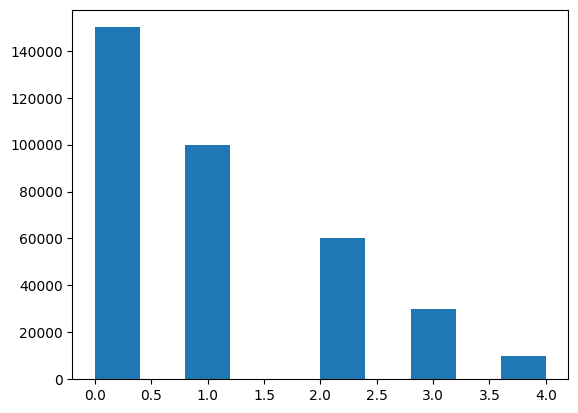

In [29]:

plt.hist(y_bb)

(array([ 1181.,  3105.,  4811., 16368., 17979., 17298.,  6677.,  2358.,
          199.,    24.]),
 array([-1.48721794,  2.64468781,  6.77659356, 10.90849931, 15.04040506,
        19.17231081, 23.30421655, 27.4361223 , 31.56802805, 35.6999338 ,
        39.83183955]),
 <BarContainer object of 10 artists>)

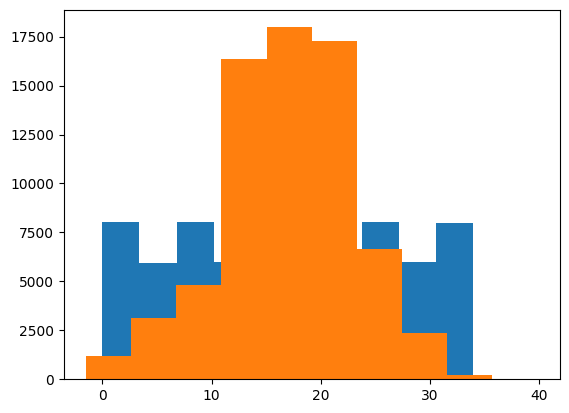

In [20]:



# np.sum(np.round(model.predict(X_val)) == y_val)/len(y_val)
import matplotlib.pyplot as plt
plt.hist(y_val)
plt.hist(model.predict(X_val))


In [20]:
arr = np.load("features_selected_T11Bg.npy",allow_pickle=True)

In [ ]:
old_label_arr = np.array([np.tile(i,10000) for i in np.arange(0,35)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

y_arr = utils_ml.convert_labels(old_label_arr, class_to_poles)
n_tasks = y_arr.shape[1]

In [22]:
def augment_data(X, y):
    n_samples = X.shape[0]
    # Repeat X for each task (shape: [n_samples * n_tasks, n_features])
    X_aug = np.repeat(X, n_tasks, axis=0)
    # Create a column with task identifiers (0, 1, 2, …)
    task_ids = np.tile(np.arange(n_tasks), n_samples).reshape(-1, 1)
    # Append the task identifier to the features
    X_aug = np.hstack([X_aug, task_ids])
    
    # Flatten y so that each target value aligns with the corresponding task
    y_aug = y.flatten()
    return X_aug, y_aug

# Augment both training and validation datasets
X_train_aug, y_train_aug = augment_data(arr, y_arr)

In [23]:
X_train_aug.shape,y_train_aug.shape

((1050000, 129), (1050000,))

In [25]:
np.save('labels_3_selected_T11Bg.npy', y_train_aug)

In [ ]:
stop

In [16]:
feature_names = np.load("feature_names.npy",allow_pickle=True)
features = np.load("features_filtered_T11Bg.npy",allow_pickle=True)[0].astype(np.float32)
features_selected = np.load("features_selected_T11Bg.npy",allow_pickle=True)[0].astype(np.float32)

features_list = features.tolist()
selected_names = []
cnt = 0 

for val in features_selected:
    # Find all indices where the value matches (in case of duplicates)
    matches = [i for i, x in enumerate(features_list) if x == val]

    # If unique match, grab the name
    if len(matches) == 1:
        selected_names.append(feature_names[matches[0]])
    else:
        # raise ValueError(f"Non-unique or missing match for selected value: {val}")
        cnt += 1

print("Selected feature names:", selected_names)

Selected feature names: ['intensity__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"min"', 'intensity__fft_coefficient__attr_"imag"__coeff_2', 'intensity__cwt_coefficients__coeff_1__w_10__widths_(2, 5, 10, 20)', 'intensity__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"mean"', 'intensity__cwt_coefficients__coeff_2__w_10__widths_(2, 5, 10, 20)', 'intensity__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"max"', 'intensity__agg_linear_trend__attr_"rvalue"__chunk_len_10__f_agg_"var"', 'intensity__agg_linear_trend__attr_"intercept"__chunk_len_10__f_agg_"var"', 'intensity__cid_ce__normalize_True', 'intensity__fft_coefficient__attr_"angle"__coeff_4', 'intensity__agg_linear_trend__attr_"slope"__chunk_len_50__f_agg_"var"', 'intensity__fft_coefficient__attr_"angle"__coeff_9', 'intensity__cwt_coefficients__coeff_0__w_5__widths_(2, 5, 10, 20)', 'intensity__fourier_entropy__bins_100', 'intensity__fft_coefficient__attr_"real"__coeff_1', 'intensity__skewness', 'intensity__

In [17]:
len(selected_names)

93

In [2]:
import glob
import pickle

# Get all matching files
files = glob.glob("fold_accuracies*.pkl")

# Separate files into raw and normal
raw_files = [f for f in files if "raw" in f]
normal_files = [f for f in files if "raw" not in f]

# Load the data
raw_data = [pickle.load(open(f, "rb")) for f in raw_files]
normal_data = [pickle.load(open(f, "rb")) for f in normal_files]


In [3]:
len(normal_data)

5

In [4]:

feat_to_per_dict = {}
feature_percentages = np.logspace(-2, 0, 5)[:-1]  # From 1% to 100% of features
feature_counts = np.unique(
    np.clip((feature_percentages * 75).astype(int), 1, 75)
)
feat_to_per_dict = {int(feat): per for feat, per in zip(feature_counts, feature_percentages)}
feat_to_per_dict


{1: 0.01,
 2: 0.03162277660168379,
 7: 0.09999999999999999,
 23: 0.31622776601683794}

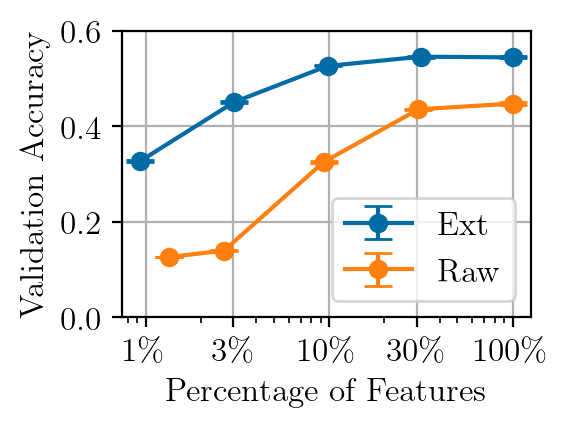

In [16]:
def get_stats(data):
    feature_counts = []
    accuracy_lists = []

    for item in data:
        for count, accuracies in item.items():
            feature_counts.append(count)
            accuracy_lists.append(accuracies)

    # Sort data by feature count
    sorted_indices = np.argsort(feature_counts)
    feature_counts = [feature_counts[i] for i in sorted_indices]
    accuracy_lists = [accuracy_lists[i] for i in sorted_indices]

    # Calculate means and standard deviations
    means = [np.mean(accuracies) for accuracies in accuracy_lists]
    stds = [np.std(accuracies) for accuracies in accuracy_lists]

    return means, stds, feature_counts

means_r, stds_r, feature_counts_r = get_stats(raw_data)
means_n, stds_n, feature_counts_n = get_stats(normal_data)

# Create the plot
plt.figure(figsize=(3, 2.3))
plt.errorbar(100 * np.array(feature_counts_n) / 429, means_n, yerr=stds_n, fmt='-o', capsize=5,label="Ext")
plt.errorbar(100 * np.array(feature_counts_r) / 75, means_r, yerr=stds_r, fmt='-o', capsize=5,label="Raw")
plt.xscale('log')
plt.xticks([1, 3, 10, 30, 100], labels=["1\%", "3\%", "10\%", "30\%", "100\%"])
plt.xlabel("Percentage of Features")
plt.ylabel("Validation Accuracy")
# plt.title("Effect of Feature Count on Accuracy")
plt.grid(True)
plt.ylim(0,0.6)
plt.tight_layout()
plt.legend()
plt.savefig("feature_selec.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [6]:
stop

NameError: name 'stop' is not defined

In [1]:
# # Plotting mean ± std as error bars
# means = [np.mean(acc_dict[d]) for d in feature_counts]
# stds = [np.std(acc_dict[d]) for d in feature_counts]

# plt.figure(figsize=(8, 6))
# plt.errorbar(100 * feature_counts / 429, means, yerr=stds, fmt='-o', capsize=5)
# plt.xscale('log')
# plt.xticks([1, 3, 10, 30, 100], labels=["1%", "3%", "10%", "30%", "100%"])
# plt.xlabel("Percentage of Features (log scale)")
# plt.ylabel("Validation Accuracy")
# plt.title("Effect of Feature Count on Accuracy")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [ ]:
X_arr = np.load('features_filtered_T11Bg.npy', mmap_mode='r+')
sel = VarianceThreshold(threshold=(.9 * (1 - .9)))
X_arr = sel.fit_transform(X_arr)



In [ ]:
# Initialize an empty list to hold all feature arrays
feature_list = []

# Loop from 0 to 34 (inclusive)
for i in range(35):
    # Format the filename with leading zeros (e.g., P00, P01, ..., P34)
    filename = f"rawFeatures/P{i:02d}_intensity.pkl"
    
    # Load the file and append to the list
    features = np.array(np.load(filename, allow_pickle=True))
    feature_list.append(features)

# Concatenate all arrays along axis 0
X_arr_raw = np.concatenate(feature_list, axis=0)


In [ ]:
# X_arr.shape, np.load('features_filtered_T11Bg.npy', mmap_mode='r+').shape

In [ ]:
# X_arr = np.load('features_selected.npy', mmap_mode='r+')

In [ ]:
# Load and concatenate all features
file_prefix = "rawFeatures/P"
file_suffix = "_intensity.pkl"
num_files = 35

class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}


y_arr_classification = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()
y_arr_regression = utils_ml.convert_labels(y_arr_classification, class_to_poles)*1.0

In [ ]:
rg = CatBoostRegressor(
    iterations=1000,
    verbose=100,
    loss_function="MultiRMSE",
    early_stopping_rounds=10 
    )
X_train, X_val, y_train, y_val = train_test_split(X_arr_raw, y_arr_regression, random_state=42, test_size=0.2)
rg.fit(X_train, y_train, eval_set=(X_val,y_val), plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.8636190	test: 1.8638414	best: 1.8638414 (0)	total: 134ms	remaining: 2m 13s
100:	learn: 1.0079673	test: 1.0083718	best: 1.0083718 (100)	total: 7.78s	remaining: 1m 9s
200:	learn: 0.9180284	test: 0.9185369	best: 0.9185369 (200)	total: 15s	remaining: 59.6s
300:	learn: 0.8711828	test: 0.8720866	best: 0.8720866 (300)	total: 22.3s	remaining: 51.9s
400:	learn: 0.8411279	test: 0.8421693	best: 0.8421693 (400)	total: 30s	remaining: 44.8s
500:	learn: 0.8182153	test: 0.8196583	best: 0.8196583 (500)	total: 37.4s	remaining: 37.2s
600:	learn: 0.8010659	test: 0.8029383	best: 0.8029383 (600)	total: 44.6s	remaining: 29.6s
700:	learn: 0.7868433	test: 0.7892146	best: 0.7892146 (700)	total: 51.8s	remaining: 22.1s
800:	learn: 0.7752985	test: 0.7781231	best: 0.7781231 (800)	total: 59.1s	remaining: 14.7s
900:	learn: 0.7651802	test: 0.7684763	best: 0.7684763 (900)	total: 1m 7s	remaining: 7.36s
999:	learn: 0.7572942	test: 0.7611161	best: 0.7611161 (999)	total: 1m 14s	remaining: 0us

bestTest = 0.7611

In [ ]:
accuracy_score(utils_ml.reconvert_labels(np.abs(np.round(rg.predict(X_val))), class_to_poles), utils_ml.reconvert_labels(y_val, class_to_poles))

0.4498714285714286

In [ ]:
importances = rg.get_feature_importance()
# feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]
X_arr_raw = X_arr_raw[:,sorted_idx]

In [ ]:
# np.save('features_selected.npy', X_arr[:,sorted_idx[:100]])

In [ ]:
# importances[sorted_idx][:100]

In [ ]:
# y_arr_regression[sorted_idx[:d]].shape

In [ ]:
# d_arr = [10,100,200,300,400,429]
# acc_arr = []
# for d in d_arr:
#     _rg = CatBoostRegressor(
#         verbose=100,
#         loss_function="MultiRMSE",
#         early_stopping_rounds=10 
#         )
#     X_train, X_val, y_train, y_val = train_test_split(X_arr[:,sorted_idx[:d]], y_arr_regression, random_state=42, test_size=0.2)
#     _rg.fit(X_train, y_train, eval_set=(X_val,y_val), plot=True)

#     acc_arr.append(accuracy_score(utils_ml.reconvert_labels(np.abs(np.round(_rg.predict(X_val))), class_to_poles), utils_ml.reconvert_labels(y_val, class_to_poles)))
stop

NameError: name 'stop' is not defined

In [ ]:
import numpy as np
import gc
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


feature_percentages = np.logspace(-2, 0, 5)
feature_counts = np.unique(np.clip((feature_percentages * X_arr_raw.shape[1]).astype(int), 1, X_arr_raw.shape[1]))

# Dictionary to hold fold accuracies per feature count
acc_dict = {}
fold_accuracies = []
for d in feature_counts:
    print(f"\nEvaluating {d} features ({d/75:.1%} of total)...")
    

    # kf = KFold(n_splits=5, shuffle=True, random_state=42)
    # for fold, (train_index, val_index) in enumerate(kf.split(X_arr)):
    X_train, X_val = X_arr_raw[:, :d], X_arr_raw[:, :d]
    y_train, y_val = y_arr_regression, y_arr_regression

    model = CatBoostRegressor(
        iterations=1000,
        verbose=0,
        loss_function="MultiRMSE",
        early_stopping_rounds=10
    )

    model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

    # Save model
    # model_path = f"savedModels/catboost_model_{d}_fold{fold}.cbm"
    # model.save_model(model_path)

    # Predict and evaluate
    y_pred = np.abs(np.round(model.predict(X_val)))
    acc = accuracy_score(
        utils_ml.reconvert_labels(y_pred, class_to_poles),
        utils_ml.reconvert_labels(y_val, class_to_poles)
    )
    fold_accuracies.append(acc)

    # Clean up
    del model
    gc.collect()

acc_dict[d] = fold_accuracies
print(f"Fold Accuracies: {fold_accuracies}")

# Plotting mean ± std as error bars
# means = [np.mean(acc_dict[d]) for d in feature_counts]
# stds = [np.std(acc_dict[d]) for d in feature_counts]

# plt.figure(figsize=(4, 3))
# plt.errorbar(100 * feature_counts / 429, means, yerr=stds, fmt='-o', capsize=5)
# plt.xscale('log')
# plt.xticks([1, 3, 10, 30, 100], labels=["1%", "3%", "10%", "30%", "100%"])
# plt.xlabel("Percentage of Features (log scale)")
# plt.ylabel("Validation Accuracy")
# plt.title("Effect of Feature Count on Accuracy")
# plt.grid(True)
# plt.tight_layout()
# plt.show()


Evaluating 1 features (1.3% of total)...

Evaluating 2 features (2.7% of total)...

Evaluating 7 features (9.3% of total)...

Evaluating 23 features (30.7% of total)...

Evaluating 75 features (100.0% of total)...
Fold Accuracies: [0.12864285714285714, 0.13929142857142857, 0.3277685714285714, 0.43968, 0.45112]


In [ ]:
fold_accuracies

[0.45310285714285714]

In [ ]:
clf = CatBoostClassifier(
    iterations=100
    loss_function="MultiClass",
    class_weights=None,
    auto_class_weights=None,
    verbose=100,
    early_stopping_rounds=10,        
)
X_train, X_val, y_train, y_val = train_test_split(X_arr, y_arr_classification,random_state=42, test_size=0.2)
clf.fit(X_arr[:,:100], y_arr_classification, eval_set=(X_val[:,:100],y_val),plot=True)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1381764609.py, line 2)

In [ ]:
accuracy_score(clf.predict(X_val),y_val)

CatBoostError: There is no trained model to use predict(). Use fit() to train model. Then use this method.

In [ ]:
# percentages = [0.5,0.75,0.9]
# num_features = X_train.shape[1]

# feature_importances = clf.get_feature_importance()
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

# # Rank features by importance
# ranked_features = sorted(zip(feature_names, feature_importances), key=lambda x: x[1], reverse=True)

# # Store results
# results = {}

# # Train and evaluate for each percentage
# for percent in percentages:
#     k = max(1, int(percent * num_features))  # Number of features to select
#     top_features = [name for name, importance in ranked_features[:k]]
#     selected_columns = [feature_names.index(name) for name in top_features]
    
#     # Reduce dataset
#     X_train_selected = X_train[:, selected_columns]
#     X_val_selected = X_val[:, selected_columns]
    
#     # Train with selected features
#     clf_reduced = CatBoostClassifier(verbose=100)
#     clf_reduced.fit(X_train_selected, y_train)
    
#     # Evaluate accuracy
#     y_pred = clf_reduced.predict(X_val_selected)
#     acc = accuracy_score(y_val, y_pred)
#     results[percent] = acc

# print("Accuracy with top features:")
# for percent, acc in results.items():
#     print(f"Top {int(percent * 100)}% features: {acc:.4f}")

In [ ]:

# # Define a range of thresholds to test
# thresholds = np.arange(1, X_train.shape[1], 5)  # 50 thresholds between 0 and 0.5
# accuracies = []
# num_features_list = []

# best_accuracy = 0
# best_threshold = 0
# best_num_features = X_train.shape[1]

# for threshold in thresholds:
#     selector = SelectKBest(f_classif, k=int(threshold))
#     X_train_selected = selector.fit_transform(X_train, y_train)
#     X_test_selected = selector.transform(X_val)
    
#     # Initialize and fit a HistGradientBoostingClassifier with isotonic calibration
#     clf_reduced = CatBoostClassifier(verbose=100)
#     clf_reduced.fit(X_train_selected, y_train)
    
#     # Evaluate accuracy
#     y_pred = clf_reduced.predict(X_test_selected)
#     accuracy = accuracy_score(y_val, y_pred)
    
#     # Keep track of accuracy and number of features
#     num_features = X_train_selected.shape[1]
#     accuracies.append(accuracy)
#     num_features_list.append(num_features)
    
#     # Keep track of the best threshold based on accuracy and feature count
#     if accuracy > best_accuracy or (accuracy == best_accuracy and num_features < best_num_features):
#         best_accuracy = accuracy
#         best_threshold = threshold
#         best_num_features = num_features

# # Plot threshold vs number of features
# plt.figure(figsize=(10, 6))
# plt.plot(num_features_list, accuracies, label="Number of Features", color='blue', marker='o')
# plt.ylabel("Accuracy")
# plt.xlabel("Number of Features")
# plt.title("Threshold vs Number of Features")
# plt.grid(True)

# plt.show()

# # Print the best threshold and accuracy information
# print(f"Best Threshold: {best_threshold:.4f}")
# print(f"Best Accuracy: {best_accuracy:.4f}")
# print(f"Number of Features: {best_num_features}")
